# Data Analysis and Reporting with Structured Querying Language (SQL)

**🎯 Lesson Objectives**

**By the end of this lesson, you will be able to:**

- Understand SQL techniques for Data manipulation
- Use advanced SQL techniques to optimise database queries
- Understand Database indexes

**🎯What we will cover:**

**Part 1 - Data manipulation**
- Setting up the database connection
- Shop database table structure (schema)
- Schema deep dive
- Relational database table constraints
- DROP AND CREATE
- INSERT
- UPDATE
- DELETE


**Part 2 - Optimising queries**
- DB index: concept
- DB index: syntax


---



## ☑️ Setting up the database connection

First, import pandas and sqlite3 libraries and create the connection to the `shop_db.db` database, located in the `data` folder:

In [1]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('data/shop_db.db')

## ☑️ Shop database table structure (schema)
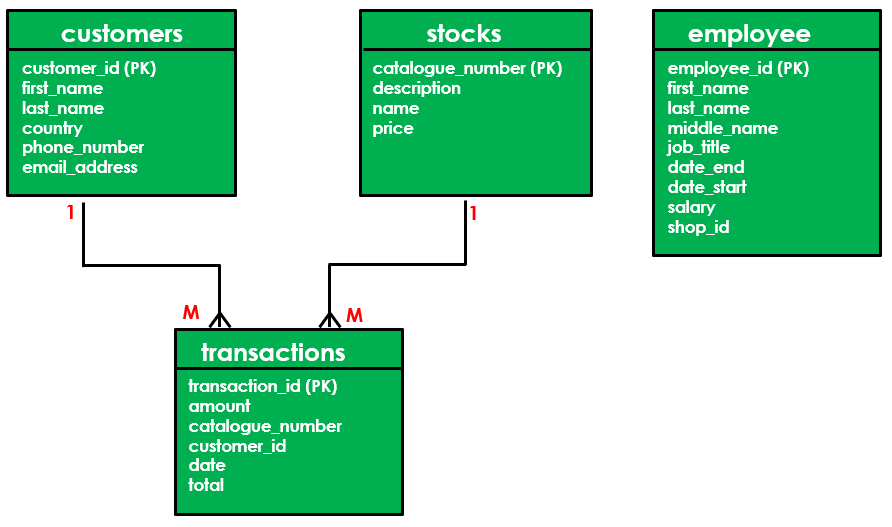

The customers table tracks all customer information, the stocks table tracks all product information, the transaction table tracks all transactions that had taken place and the employee table tracks information related to company employees. 

As illustrated above customer-transactions and stocks-transactions tables are having one-to-many relationships. Also please note the employee table is not connected to any other table.

## ☑️ Shop database table structure (schema)

In [2]:
query = """
SELECT name 
FROM sqlite_master 
WHERE type = 'table';
"""
df = pd.read_sql_query(query, conn)
df


,name
0,customers
1,stocks
2,transactions
3,employees


In [3]:
for table in ['customers', 'stocks', 'transactions', 'employees']:
    
    query = f"""
    SELECT sql 
    FROM sqlite_master 
    WHERE name = '{table}';
    """
    
    df = pd.read_sql_query(query, conn)
    print(''.join(df.values[0, 0]))

CREATE TABLE "customers" (
	`customer_id`	INTEGER,
	`first_name`	TEXT,
	`last_name`	TEXT,
	`country`	TEXT,
	`phone_number`	TEXT,
	`email_address`	TEXT,
	PRIMARY KEY(`customer_id`)
)
CREATE TABLE "stocks" (
	`catalogue_number`	INTEGER,
	`name`	TEXT NOT NULL,
	`description`	TEXT,
	`price`	REAL NOT NULL CHECK(price > 0),
	PRIMARY KEY(`catalogue_number`)
)
CREATE TABLE "transactions" (
	`transaction_id`	INTEGER,
	`customer_id`	TEXT NOT NULL,
	`catalogue_number`	INTEGER NOT NULL,
	`amount`	INTEGER NOT NULL,
	`date`	DATETIME,
	`total`	REAL NOT NULL,
	PRIMARY KEY(`transaction_id`)
)
CREATE TABLE employees (
    employee_id INTEGER PRIMARY KEY,
    shop_id INTEGER NOT NULL,
    first_name TEXT NOT NULL,
    middle_name TEXT,
    last_name TEXT NOT NULL,
    job_title TEXT NOT NULL,
    salary FLOAT NOT NULL,
    date_start DATETIME NOT NULL,
    date_end DATETIME
)


## **🔄 Recap: Key Elements from last session**  

Before learning **Data manipulation**, it is important to understand some fundamental concepts. Below is an overview of key topics to grasp from our previous session.

**Question 1**

What is the primary function of a **SQL JOIN**?  

- **A)** To **combine columns** from multiple tables into a single table  
- **B)** To create a **new table** by copying data from another table  
- **C)** To **filter out duplicate values** from a table  
- **D)** To **update multiple rows** in a table at once  

In [4]:
#put your answer below



**Question 2**

What is the difference between a **LEFT JOIN** and an **INNER JOIN** in SQL?  

- **A)** A **LEFT JOIN** returns **all records from the left table** and **matching records from the right table**, while an **INNER JOIN** only returns records that have **matching values in both tables**  
- **B)** A **LEFT JOIN** removes **duplicate rows**, while an **INNER JOIN** does not  
- **C)** An **INNER JOIN** always includes **NULL values**, while a **LEFT JOIN** does not  
- **D)** **LEFT JOINs** are only used with **numeric data**, while **INNER JOINs** work with **any data type**  

In [5]:
#put your answer below



**Question 3**

Write a SQL query to retrieve all customer first names and total transaction amounts, ensuring that all customers are included in the results even if they have no transactions.

**Fill in the blanks to the SQL statement below:**

```sql
SELECT customers._______, transactions.________
FROM customers
____ JOIN transactions 
ON ;
```

In [6]:
#Write your SQL query here

query = """
SELECT customers.first_name, transactions.total
FROM customers
LEFT JOIN transactions 
ON customers.customer_id = transactions.customer_id
"""
df = pd.read_sql_query(query, conn)
df

,first_name,total
0,Alice,30.6
1,Alicia,NaN
2,Arthur,7.0
3,Emma,NaN
4,Nargess,5.1
5,Nargess,120.0
6,Rupert,NaN


**Question 4**

Write a SQL query to find the total amount spent by each customer, but only include customers who have spent more than £50.**  

- Use a **JOIN** to combine the `customers` and `transactions` tables.  
- Apply the **SUM()** function to calculate the total amount spent by each customer.  
- Use **GROUP BY** to group results by `customer_id`.  
- Use **HAVING** to filter customers who have spent more than £50.  


**Fill in the blanks to the SQL statement below:**
```sql
SELECT customers.first_name, customers.last_name, ___ (transactions.total) AS total_spent
FROM _______
JOIN _______ 
ON customers.customer_id = transactions.customer_id
GROUP BY ____________.______________
HAVING total_spent > __;
```

In [7]:
#Write your SQL query here

query = """

SELECT customers.first_name, customers.last_name, SUM (transactions.total) AS total_spent
FROM customers
LEFT JOIN transactions
ON customers.customer_id = transactions.customer_id
GROUP BY customers.customer_id
HAVING total_spent > 50
"""
df = pd.read_sql_query(query, conn)
df

,first_name,last_name,total_spent
0,Nargess,Newton-Jones,125.1


---




# 🚀 Part 1 - Data Manipulation

The next step in SQL is talking about how we can actually manipulate the data in our database. 

So far we have assumed that the data is all there with a predefined set of types, and we never need to insert or update it. We mainly relied on SQL SELECT statement for retrieving and analysing data.

Data manipulation in SQL involves changing or modifying existing data in a database. Here are some commonly used SQL statements for data manipulation: INSERT, UPDATE, DELETE, ALTER. 

There are other SQL statements as well, such as CREATE TABLE, DROP TABLE, and INDEX, which are used for creating tables, deleting tables, and creating indexes respectively.

Now, we're going to talk about making changes to the data in the database.

## SQL Table schema deep dive

- The schema of a table refers to the table name, columns and types.
- Tables are flat.
- Reminder of basic data types:
  - NULL 
  - INT
  - REAL: for real numbers with decimal
  - TEXT: of unspecified length
  - BLOB: bytes e.g. storing images
  - BOOLEAN
- Find all datatypes e.g. [here](https://www.journaldev.com/16774/sql-data-types#sql-data-types-important-points)

A table schema is a blueprint or a plan that outlines the structure of a database table.

When you are setting up a database, you need to define a *schema*. A schema defines: the name of the table, the names and types of the columns, and constraints if necessary (for example if it's an ID, maybe it needs to be UNIQUE). 

Tables in SQL are always flat - there are no multi-indexes, you can't have a group of rows or columns like you might do in Excel. Any hierarchies have to be built by your queries. 

So in total, your schema will be a table name, and a list of the columns, annotated by types and constraints. 

#### 💡 Knowledge Check 1

What does a **SQL table schema** define?  

- **A)** The **data values** stored in each column  
- **B)** The **structure** of a table, including **column names, data types, and constraints**  
- **C)** The **queries** used to manipulate the table  
- **D)** The **relationships** between multiple tables  

In [8]:
#put your answer below



## ☑️ Relational database table constraints

In a relational database, constraints are rules that are used to enforce data integrity and ensure that data is consistent and accurate.

Also helps prevent data entry errors and helps maintain the integrity of the data stored in the database tables.

There are several types of constraints that can be used in a relational database, including:

- Properties that a table must comply with.
- Types of constraints:
  - NOT NULL: value must not be NULL.
  - UNIQUE:  value must be unique for each row in a table.
  - PRIMARY KEY: value must be unique and not NULL. Used to identify individual records.
  - FOREIGN KEY: value must reference an existing record in another table.
  - CHECK: must evaluate to true for constraint to be satisfied

The possible constraints are as follows:
1. NOT NULL - means that this field cannot be empty. For example, this might be an address if you were entering your shipping details on an online order. 
2. UNIQUE - this means that no two rows can have the same value in this column. 
3. PRIMARY KEY - this combines UNIQUE and NOT NULL. This is most used for unique IDs - e.g. we don't want several customers to have the same ID, otherwise, we won't be able to associate transactions to them individually. 
4. FOREIGN KEY - this means that this ID appears in another table. For example, when we joined the transactions and people tables above, we used a foreign key, the customer ID.
5. CHECK - this allows us to specify a CHECK which must be true (e.g. age must be a positive number). 

---

#### 💡 Knowledge Check 2

What is the purpose of a **PRIMARY KEY** constraint in a relational database?  

- **A)** It ensures that a column **cannot have NULL values**  
- **B)** It guarantees that a column contains **only unique values**  
- **C)** It **uniquely identifies** each record in a table by ensuring values are **both unique and not NULL**  
- **D)** It enforces that a column **references another table**  

In [9]:
#put your answer below



## ☑️ DB Browser for SQLite

DB Browser for SQLite is a free and open-source graphical user interface (GUI) tool for working with SQLite databases. 

It provides an easy-to-use interface for exploring data types and constraints in tables.

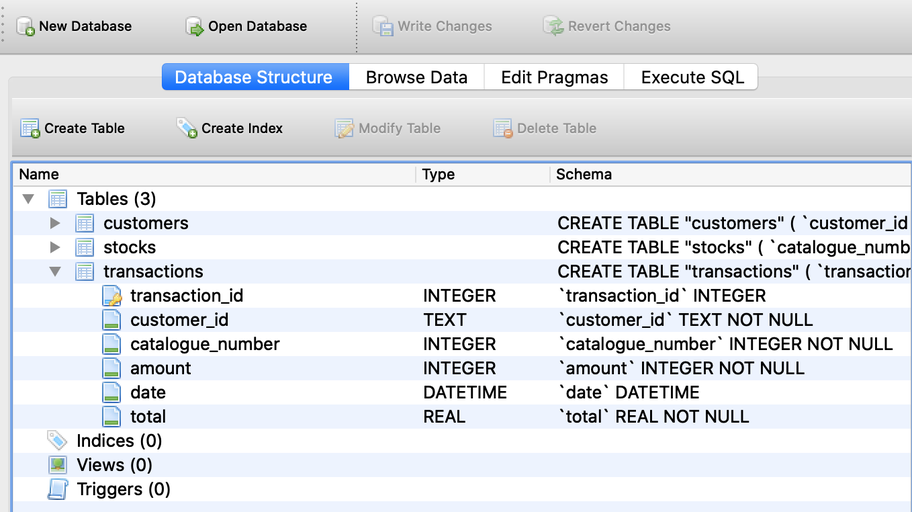

Often when you need to familiarise yourself with some data, or you are in the process of constructing a query, you will want to take a look at the schema to check the types and constraints. 

Many platforms come with graphical interfaces to let us view details about our database. This is an example of DB Browser - here we can see that for the table "transactions" we have the columns, the types, and on the right, we have the schema that defines that column (i.e. the name, the type, and the constraints). For example, "customer" is given the type TEXT, and we can see in the schema it needs to be NOT NULL.

## ☑️ DROP AND CREATE

- DROP: removes a table **if exists**
- CREATE: creates a new table from scratch
- You can add IF NOT EXISTS to avoid creating twice
- This defines the **schema** but **not the data**

Here are two keywords for interacting with schema.

The first is DROP - this is used for deleting a whole table. This is particularly useful when you're first designing and testing your table schema, and might come in handy during the exercises when you're running/re-running code. It's common to see "DROP TABLE IF EXISTS tablename" which says if the table already exists, drop it, if not do nothing.

The second is CREATE - this is used to create a table. We follow the CREATE with the table name and the table schema - we don't use it to actually fill in any data. As with "DROP" we can use existence to tell us what to do (i.e. we could write CREATE TABLE tablename IF NOT EXISTS). 


## DROP AND CREATE

In [10]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("data/shop_db.db")

cur = conn.cursor()

cur.execute("DROP TABLE IF EXISTS employees;")

query = """
CREATE TABLE IF NOT EXISTS employees (
    employee_id INTEGER PRIMARY KEY,
    shop_id INTEGER NOT NULL,
    first_name TEXT NOT NULL,
    middle_name TEXT,
    last_name TEXT NOT NULL,
    job_title TEXT NOT NULL,
    salary FLOAT NOT NULL,
    date_start DATETIME NOT NULL,
    date_end DATETIME
);
"""
cur.execute(query)
conn.commit()
# good practice to close the DB after modifying it
conn.close()

Putting this all together now, we can connect to our shop database and create a new table. First, we "DROP" the table if it exists already. 

Next, we use CREATE TABLE employees to specify the schema, which is composed of some IDs, the name, title, salary, and start/end dates of employment.

Remember we're not uploading any data here: we're just specifying some information about the shape of the dataset.

#### 💡 Knowledge Check 3

What does the SQL command `DROP TABLE IF EXISTS employees;` do?  

- **A)** It **deletes all records** from the `employees` table but **keeps the table structure**  
- **B)** It **permanently removes** the `employees` table if it exists  
- **C)** It **creates** the `employees` table if it does not already exist  
- **D)** It **updates the schema** of the `employees` table  

In [11]:
#put your answer below



## ☑️ INSERT

In SQL we are be able to add new data to the database with "INSERT" queries.

As usual, we need to specify a table to be inserted into. So if we want to insert into "employees" then we write "INSERT INTO employees". 

Next, specify the list of columns for which we are providing data (in this case all of them). Then we write VALUES and include the values that we want to insert into each of the columns. 

This scales up, so if we have lots of rows to insert, we could specify the columns once and then have multiple rows of values (as long as we're always inserting the same columns!) 

In [12]:
conn = sqlite3.connect("data/shop_db.db")
cur = conn.cursor()

query = """
INSERT INTO employees (employee_id, shop_id, first_name, middle_name, last_name, job_title, salary, date_start, date_end)
VALUES (1, 5, 'Cristiano', NULL, 'Ronaldo dos Santos Aveiro', 'LOAT', 0, datetime('2002-10-07'), NULL)
"""

cur.execute(query)
conn.commit()

In [13]:
query = """
SELECT * 
FROM employees;
"""

df = pd.read_sql_query(query, conn, index_col="employee_id")
conn.close()
df

,shop_id,first_name,middle_name,last_name,job_title,salary,date_start,date_end
employee_id,,,,,,,,
1,5,Cristiano,None,Ronaldo dos Santos Aveiro,LOAT,0.0,2002-10-07 00:00:00,None


As usual, we can check that we correctly inserted by selecting everything and printing out the full table (and we have because we can see the new row in the table!) 

## ☑️ UPDATE

Beyond creating tables and selecting from them, there are some other fundamental operations that appear in every dialect of SQL. The first of these is UPDATE, which we use to modify entries. 

UPDATE takes as its first argument a table name, e.g. in this example we're updating the table "employees".

Next, we tell SQL which column we want to update (in this case we're setting "salary" to be the new value). With `sqllite` we can build our query up using variables, so here we write "SET salary equals question mark". 

If instead of the question mark we wrote 999 then we would be updating the salary to be 999. Next, we need to specify which row (or rows) this applies to! For example, maybe we want to raise salaries for all of one specific level of employee. 

To keep it simple we'll just update everyone with a specific first_name using the clause "WHERE first_name= ?".

In the line underneath, we set both values: 110 (for the salary) and Lionel (for the first_name).

The result is that any row where the first_name field is Lionel will have their salary set to 110. 

We can check that this is the case by selecting all of the employees from the table and printing them out.

In [14]:
conn = sqlite3.connect("data/shop_db.db")
cur = conn.cursor()

query = """
UPDATE employees
SET salary=? 
WHERE first_name=?;
"""

values = ('110', 'Cristiano')
cur.execute(query, values)

conn.commit()

df = pd.read_sql_query("SELECT * FROM employees", conn, index_col="employee_id")

conn.close()
df

,shop_id,first_name,middle_name,last_name,job_title,salary,date_start,date_end
employee_id,,,,,,,,
1,5,Cristiano,None,Ronaldo dos Santos Aveiro,LOAT,110.0,2002-10-07 00:00:00,None


#### 💡 Knowledge Check 4

What is the correct SQL syntax to insert a new employee record into the `employees` table?  

```sql
A) INSERT INTO employees 
   VALUES ('1', '5', 'Cristiano', NULL, 'Ronaldo dos Santos Aveiro', 'LOAT', 0, '2002-10-07', NULL);

B) INSERT INTO employees (employee_id, shop_id, first_name, middle_name, last_name, job_title, salary, date_start, date_end) 
   VALUES (1, 5, 'Cristiano', NULL, 'Ronaldo dos Santos Aveiro', 'LOAT', 0, '2002-10-07', NULL);

C) ADD INTO employees  
   VALUES (1, 5, 'Cristiano', NULL, 'Ronaldo dos Santos Aveiro', 'LOAT', 0, '2002-10-07', NULL);

D) UPDATE employees  
   SET (employee_id, shop_id, first_name, middle_name, last_name, job_title, salary, date_start, date_end)  
   VALUES (1, 5, 'Cristiano', NULL, 'Ronaldo dos Santos Aveiro', 'LOAT', 0, '2002-10-07', NULL);
```

In [15]:
#put your answer below



## ☑️ DELETE

Another thing we might find we want to do is to remove items from the table! Imagine an employee no longer works at the company and we don't want to store their details anymore.

We do this in a very similar way to updating: first, we specify the table using "DELETE FROM table name". Then we specify the row (or rows) we want to remove. We can do this with a WHERE clause just like with update: in this case, we'll remove all employees whose first names are "Cristiano". 

Again we can select and print out the whole table to check that the change occurred.

In [16]:
conn = sqlite3.connect("data/shop_db.db")
cur = conn.cursor()

query = """
DELETE FROM employees
WHERE first_name='Cristiano'
"""

cur.execute(query)
conn.commit()

In [17]:
query = """
SELECT * 
FROM employees;
"""

df = pd.read_sql_query(query, conn, index_col="employee_id")
conn.close()
df

,shop_id,first_name,middle_name,last_name,job_title,salary,date_start,date_end
employee_id,,,,,,,,


So now in addition to being able to read from databases, you know how to insert, update, and delete from tables.

We also talked about joining tables together to collate information from multiple tables, which means you now have the skills to manage and use databases of practical sizes.

# 🚀 Part 2 - Optimising Queries

By this point you should be able to create database tables, insert data into them, delete or modify entries, and perform complex SELECT queries that collate information from several tables. 

Now we're going to talk about how to make the most efficient use of our databases, and how to take advantage of the more advanced functionality in SQL.

## ☑️ Database Index: concept

One of the easiest ways to improve the efficiency of our database management is to create an index over the things we access often.

A database index is a data structure that acts as a helper for various queries and helps us to quickly locate the entries we're looking for. The reason we don't have them by default is that they have some memory overhead, so you should only use them when the speed benefits will outweigh the storage cost.

You can think of them as being much like the index page in a book, where similar topics are organised into chapters, and we can jump to a relevant chapter using the index to find the block of pages we want.


Usages:
- Fast lookup: when we create an index, SQL can make our WHERE, ORDER BY clauses and JOINs much faster because it can index the sub-set of the data that we want to query.

- Indexes help a lot in cases where comparison on raw key value is required as they avoid full table scans e.g. first_name == 'John'

- Policing and Constraints: just like with regular database schema, we can issue constraints on our index. For instance, if we put the keyword UNIQUE on the index of a column, this would prevent non-unique entries from being put in the column.

- Can be **useless** for certain queries where exact matches are not used, e.g. email LIKE '%@cambridgespark.com'. This problem is a great use case for reverse indexing


Sometimes what we really want is the *opposite* of an index. Consider the book example, where the book is organised so that chapters represent topics, and each chapter contains subtopics. In a regular index, I know the topic and I want to find the page it starts on. In the case of reverse indexing, I know a subtopic and I want to know what the overall chapter is called. This is called a reverse or inverse index, and it functions in much the same way (so the knowledge you acquire here will be transferrable).

## ☑️ Database Index: syntax

```SQL
CREATE INDEX index_name
ON table_name (column1, column2, ...);
```

The syntax for creating an index is very simple: we just specify the columns we want to index, the name of the index (in case we have many), and the table we're applying the index to. 

Here's the code that would be needed to create an index on the customers table of our shop data. Imagine we know that we want to make lots of queries based on `first_name` - we can create an index over it to make it very fast to access each name.

In [18]:
import sqlite3
conn = sqlite3.connect("data/shop_db.db")

cur = conn.cursor()

cur.execute("DROP INDEX IF EXISTS cspark_index;")

query = """
CREATE INDEX cspark_index
ON customers (first_name);
"""

cur.execute(query)
conn.commit()

In [19]:
query = """
SELECT *
FROM sqlite_master;
"""
df = pd.read_sql_query(query, conn)
df


,type,name,tbl_name,rootpage,sql
0,table,customers,customers,5,"CREATE TABLE ""customers"" (\n\t`customer_id`\tI..."
1,table,stocks,stocks,2,"CREATE TABLE ""stocks"" (\n\t`catalogue_number`\..."
2,table,transactions,transactions,3,"CREATE TABLE ""transactions"" (\n\t`transaction_..."
3,table,employees,employees,4,CREATE TABLE employees (\n employee_id INTE...
4,index,cspark_index,customers,7,CREATE INDEX cspark_index\nON customers (first...


#### 💡 Knowledge Check 5

What is the primary purpose of creating an index in a database?  

- **A)** To increase the storage size of the database  
- **B)** To improve the speed of queries by providing faster lookup  
- **C)** To automatically delete duplicate rows in a table  
- **D)** To ensure that all queries return sorted results  

In [20]:
#put your answer below



### **🔑 Summary / Key Takeaways**
By completing this lesson, you should now be able to:
- ✅ Set up a **database connection** and understand the **shop database schema**.  
- ✅ Perform a **schema deep dive** and explore **relational database constraints**.  
- ✅ Use SQL commands to **DROP, CREATE, INSERT, UPDATE, and DELETE** data.  
- ✅ Understand the concept and syntax of **database indexes**.  


### **📝 Next Steps:**  

- **Complete the practical lab work**: Open and work through the following workbook:`advanced-sql-workbook.ipynb`. 



- **Reinforce Your Learning:** You can start exploring the assignments under the **KATE After Your Workshop** section. Take this opportunity to dive into the tasks and try answering the questions.